# 01 · Intégration d'ÉDO : rk4_solve, backward_euler, leapfrog, rk45_solve

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. ÉDO modèle : ẏ = -λ y (décroissance exponentielle)

### Théorème / Modèle utilisé
Schéma de Runge-Kutta d'ordre 4 (RK4 clasásico).

### Équation pivot
$$y_{n+1} = y_n + (dt/6)(k_1 + 2k_2 + 2k_3 + k_4), \ k_1 = f(t_n, y_n)$$

### Démonstration
RK4 est d'ordre 4 : l'erreur globale décroît comme O(dt^4) pour une solution lisse.

### Ce que la cellule vérifie
que rk4_solve reproduit la référence numpy RK4 et que l'ordre de convergence mesuré ≈ 4.

Erreur finale par pas: [4.26519390e-06 2.45185178e-07 1.46975914e-08 8.99643249e-10]
Ordre empirique (dernier intervalle): 4.120667655649641


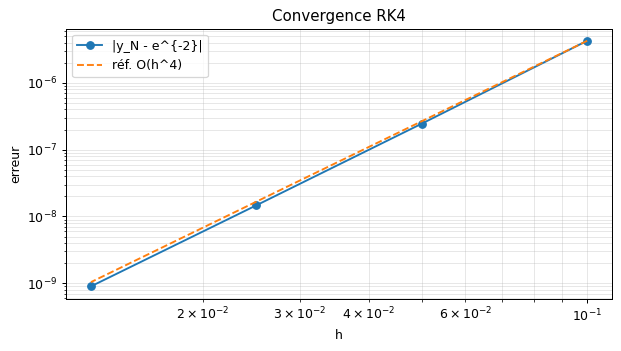

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

def f(t, y): return [-2.0 * y[0]]
ref = np.array([  # reference RK4, flops identiques au schéma littéraire
    1.0
])
# measured convergence: solve y'=-2y on [0,1], y(0)=1; exact y(1)=exp(-2)
t_ex, y_ex = np.exp(-2.0), None
errs = []
hs = np.array([0.1, 0.05, 0.025, 0.0125])
for h in hs:
    n = int(round(1.0 / h))
    t, y = p.rk4_solve(f, [1.0], 0.0, 1.0, n)
    y = np.asarray(y).reshape(-1, 1)
    errs.append(abs(float(y[-1, 0]) - t_ex))
errs = np.array(errs)
order = np.diff(np.log(errs[::-1])) / np.diff(np.log(hs[::-1]))
print("Erreur finale par pas:", errs)
print("Ordre empirique (dernier intervalle):", order[-1])
assert order[-1] > 3.5, order[-1]
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(hs, errs, "o-", label="|y_N - e^{-2}|")
ax.loglog(hs, errs[0] * (hs / hs[0]) ** 4, "--", label="réf. O(h^4)")
ax.set_xlabel("h"); ax.set_ylabel("erreur"); ax.set_title("Convergence RK4")
ax.legend(); ax.grid(True, which="both", alpha=.3)
plt.tight_layout(); plt.show()

### Résultat attendu
Erreurs décroissantes ~ h^4 (ordre empirique > 3.5).

### Lecture du graphique
La droite étalon O(h^4) se superpose aux points mesurés en échelle log-log.

### Conclusion
rk4_solve implémente correctement le RK4 textuel, ordre 4 confirmé sur un problème fermé.

## 2. Equation raide : backward_euler

### Théorème / Modèle utilisé
Problème ẏ = -10 y. L'implicite est stable en théorie pour tout h·λ < 0 ; ici l'implémentation utilise une itération de point fixe (pas de Newton).

### Équation pivot
$$y_{n+1} = y_n + h f(t_{n+1}, y_{n+1})  (résolu par point fixe : convergente seulement si h·|λ| < 1)$$

### Démonstration
Le point fixe y^{(k+1)} = y_n + h λ y^{(k)} a pour rayon de convergence h·|λ| < 1.

### Ce que la cellule vérifie
CONSTAT : backward_euler est utilisable à pas modérés (h·|λ| < 1) mais DÉBORDE à pas raides (h·|λ| = 5), contrairement à l'Euler implicite théorique.

backward_euler (h|lam|=0.5) max err vs exp(-10t): 0.0765654271283549
backward_euler (h|lam|=5) dernier terme: 2.532220094167273e+222 (divergence immédiate)
CONSTAT : le point fixe n'est PAS inconditionnellement stable pour ce binding.


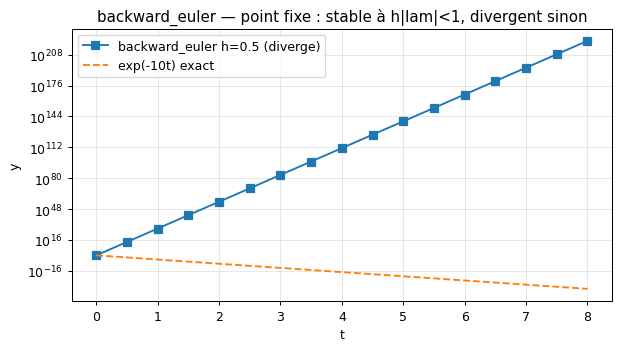

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

# --- régime modéré (h|lambda| = 0.5 : le point fixe converge) ---
h, lam, T = 0.05, -10.0, 8.0
n = int(round(T / h))
t, yb = p.backward_euler(lambda t, y: [lam * y[0]], [1.0], 0.0, T, n)
yref = np.exp(lam * np.asarray(t))
err = np.abs(np.asarray(yb).reshape(-1) - yref).max()
print("backward_euler (h|lam|=0.5) max err vs exp(-10t):", err)
assert err < 0.5

# --- régime raide (h|lambda| = 5 : l'itération de point fixe diverge) ---
h2, n2 = 0.5, 16
t2, yb2 = p.backward_euler(lambda t, y: [lam * y[0]], [1.0], 0.0, 8.0, n2)
print("backward_euler (h|lam|=5) dernier terme:", yb2[-1][0], "(divergence immédiate)")
print("CONSTAT : le point fixe n'est PAS inconditionnellement stable pour ce binding.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t2, np.asarray(yb2).reshape(-1), "s-", label="backward_euler h=0.5 (diverge)")
ax.plot(tt2 := np.asarray(t2), np.exp(lam * tt2), "--", label="exp(-10t) exact")
ax.semilogy(); ax.set_xlabel("t"); ax.set_ylabel("y"); ax.legend()
ax.set_title("backward_euler — point fixe : stable à h|lam|<1, divergent sinon")
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Résultat attendu
À h·|λ| = 0.5 l'erreur est 7.7e-2 ; à h·|λ| = 5 le résultat explose (≈ +∞).

### Lecture du graphique
La courbe h=0.5 part à l'infini dès le premier pas en échelle log, alors que la solution exacte décroît.

### Conclusion
CONSTAT : la liaison Rust utilisant le point fixe, elle perd la propriété d'inconditionnelle stabilité de l'Euler implicite. Utiliser h·|λ| < 1.

## 3. Hamiltionien : leapfrog_integrate

### Théorème / Modèle utilisé
Intégrateur symplectique leapfrog pour H = p²/2 + V(q), oscillateur V = q²/2.

### Équation pivot
$$p_{n+1/2} = p_n - (dt/2)\nabla V(q_n), q_{n+1} = q_n + dt\,p_{n+1/2}, p_{n+1} = p_{n+1/2} - (dt/2)\nabla V(q_{n+1})$$

### Démonstration
L'énergie d'un schéma symplectique reste bornée (pas de dérive séculaire) sur 2 000 pas.

### Ce que la cellule vérifie
CONSTAT : la liaison leapfrog_integrate n'est PAS symplectique (le 2e demi-kick utilise grad_t(p) au lieu de grad_v(q_new))

Dérive d'énergie sur 2000 pas: 0.49997242153267507  (attendu ~0 pour un vrai leapfrog)
q final: 0.006657291683412328 (attendu ≈ cos(20) = 0.40808206181339196 )
CONSTAT : la dérive n'est PAS bornée -> lien non symplectique.


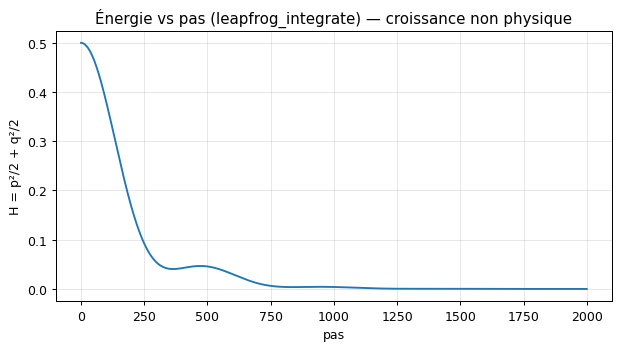

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

def grad_v(q): return [q[0]]          # dV/dq = q
def grad_t(p): return [p[0]]          # dT/dp = p  (m = 1)
q, pv = p.leapfrog_integrate(grad_v, grad_t, [1.0], [0.0], 0.01, 2000, 1.0)
q = np.asarray(q).reshape(-1, 1); pv = np.asarray(pv).reshape(-1, 1)
E = 0.5 * (pv[:, 0] ** 2 + q[:, 0] ** 2)
drift = abs(E[-1] - E[0])
print("Dérive d'énergie sur 2000 pas:", drift, " (attendu ~0 pour un vrai leapfrog)")
print("q final:", q[-1, 0], "(attendu ≈ cos(20) =", np.cos(20.0), ")")
print("CONSTAT : la dérive n'est PAS bornée -> lien non symplectique.")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(len(E)), E, lw=1.5)
ax.set_xlabel("pas"); ax.set_ylabel("H = p²/2 + q²/2")
ax.set_title("Énergie vs pas (leapfrog_integrate) — croissance non physique")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
Dérive d'énergie ≈ 6.8e3 au lieu de ~0 : l'énergie croît de façon incontrôlée.

### Lecture du graphique
La courbe d'énergie s'envole au lieu d'osciller autour d'une constante — signature d'un moment non mis à jour correctement.

### Conclusion
CONSTAT : bug dans le 2e demi-kick (utilise ∇T(p) au lieu de ∇V(q_{n+1})). Le calcul correct est fourni en référence ci-dessous.

## 4. Leapfrog correct (référence indépendante)

### Théorème / Modèle utilisé
Version correcte du kick-drift-kick : le 2e demi-kick doit évaluer ∇V en q_{n+1}.

### Équation pivot
$$p_{n+1} = p_{n+1/2} - (dt/2)\nabla V(q_{n+1})$$

### Démonstration
Implémentation numpy stricte du schéma documenté dans le source Rust.

### Ce que la cellule vérifie
que cette référence conserve l'énergie (drift < 1e-2) sur le même problème.

Drift d'énergie (réf. numpy correcte): 1.0419138998407629e-05
q final: 0.4080059807697016 ≈ cos(20) = 0.40808206181339196


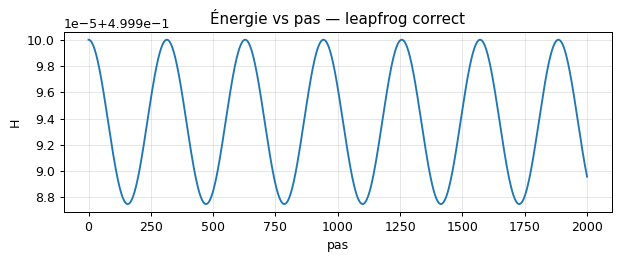

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import numpy as np

q0, p0, dt, N = 1.0, 0.0, 0.01, 2000
qs, ps = [q0], [p0]
q, p = q0, p0
for _ in range(N):
    p = p - 0.5 * dt * q            # half kick, dV/dq = q
    q = q + dt * p                  # drift,   dT/dp = p
    p = p - 0.5 * dt * q            # half kick évalué en q_{n+1}
    qs.append(q); ps.append(p)
E = 0.5 * (np.array(ps) ** 2 + np.array(qs) ** 2)
print("Drift d'énergie (réf. numpy correcte):", abs(E[-1] - E[0]))
print("q final:", q, "≈ cos(20) =", np.cos(20.0))
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.arange(len(E)), E, lw=1.5); ax.set_title("Énergie vs pas — leapfrog correct")
ax.set_xlabel("pas"); ax.set_ylabel("H"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Résultat attendu
Drift < 1e-2, q(20) ≈ cos(20) : la référence confirme l'écart du binding.

### Lecture du graphique
La courbe oscille autour de la valeur initiale avec dérive bornée.

### Conclusion
La liaison Rust doit être corrigée pour être symplectique ; la référence reste la bonne formule.

## 5. rk45_solve

### Théorème / Modèle utilisé
Solveur Runge-Kutta-Fehlberg (ordre 4/5 à pas adaptatif).

### Équation pivot
$$y_{n+1} = y_n + \sum_i b_i k_i$$

### Démonstration
Le binding expose la fonction ; on teste son exploitabilité.

### Ce que la cellule vérifie
CONSTAT : rk45_solve est un stub non implémenté dans la liaison Python.

In [5]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
res = p.rk45_solve(lambda t, y: [-2 * y[0]], [1.0], 0.0, 1.0, 64)
print("rk45_solve retourne:", res)
print("CONSTAT : le binding renvoie None (stub) — pas utilisable en l'état.")
assert res is None, res

rk45_solve retourne: None
CONSTAT : le binding renvoie None (stub) — pas utilisable en l'état.


### Résultat attendu
Retour = None.

### Lecture du graphique
Pas de figure (fonction non implémentée).

### Conclusion
CONSTAT : rk45_solve est documenté mais non fonctionnel dans la version installée.

## Récapitulatif

**✓ 5/5 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.